Regina Tamayo León

23 marzo 2026

**Métos de búsqueda**

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C


X = np.array([10,2,3,7,12]).reshape(-1,1)
y = np.array([2847,-4017,-1255,1773,563])

kernel = 1.0*RBF(length_scale=1.0)

gp = GaussianProcessRegressor(n_restarts_optimizer=10)

gp.fit(X, y)


GaussianProcessRegressor(n_restarts_optimizer=10)

In [75]:
xsim=np.linspace(2,15,10001).reshape(-1,1)

In [76]:
y_pred, sigma= gp.predict(xsim, return_std=True)
y_pred, sigma

(array([-4.01700000e+03, -4.01552264e+03, -4.01403659e+03, ...,
         2.06700829e+00,  2.05894051e+00,  2.05090082e+00]),
 array([1.00000004e-05, 8.39809338e-04, 1.67800358e-03, ...,
        9.99936160e-01, 9.99936655e-01, 9.99937147e-01]))

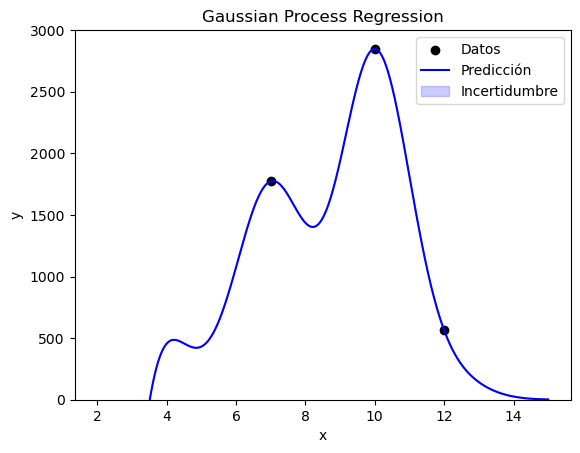

In [77]:
plt.figure()
plt.scatter(X,y,color='black',label='Datos')
plt.plot(xsim,y_pred,color='blue',label='Predicción')

plt.fill_between(
    xsim.ravel(),
    y_pred + 2*sigma,
    y_pred - 2*sigma,
    color='blue',
    alpha=0.2,
    label='Incertidumbre'
)
plt.ylim(0,3000)
plt.legend()
plt.title("Gaussian Process Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [78]:
i_max=np.argmax(y_pred+2*sigma)
i_max

np.int64(6151)

In [79]:
xsim[i_max]

array([9.9963])

Incorporación de nuevos datos

In [80]:
X1=np.array([10,2,3,7,12,9.9963]).reshape(-1,1)
y1 = np.array([2847,-4017,-1255,1773,563,2847.31363])

In [81]:
gp1 = GaussianProcessRegressor(n_restarts_optimizer=10)

gp1.fit(X1, y1)

GaussianProcessRegressor(n_restarts_optimizer=10)

In [82]:
xsim1 = np.linspace(2,15, 10001).reshape(-1,1)

In [83]:
ypred1, sigma1 = gp1.predict(xsim1,return_std=True)
ypred1, sigma1

(array([-4.01700000e+03, -4.01552264e+03, -4.01403658e+03, ...,
         2.33536929e+00,  2.32626147e+00,  2.31718532e+00]),
 array([1.00000004e-05, 8.39809338e-04, 1.67800358e-03, ...,
        9.99931110e-01, 9.99931645e-01, 9.99932175e-01]))

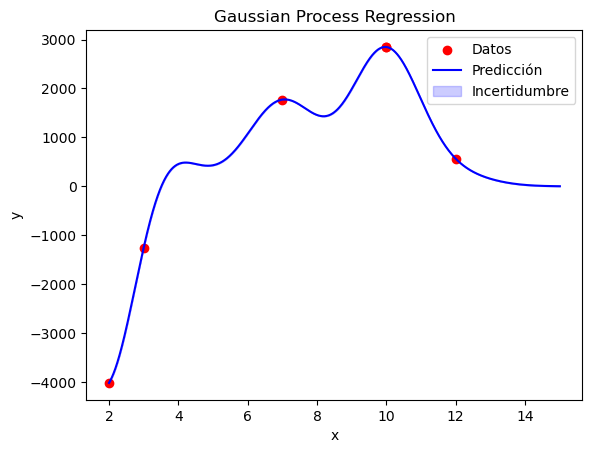

In [89]:
plt.figure()
plt.scatter(x1, y1, color='red', label='Datos')
plt.plot(xsim1, ypred1, color='blue', label='Predicción')

plt.fill_between(
    xsim1.ravel(),
    ypred1 + 2*sigma1,
    ypred1 - 2*sigma1,
    color='blue',
    alpha=0.2,
    label='Incertidumbre'
)
plt.legend()
plt.title("Gaussian Process Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [90]:
i_max1 = np.argmax(ypred1 + 2*sigma1)
i_max1

np.int64(6127)

In [92]:
xsim[i_max1]

array([9.9651])

Incorporación de nuevos datos

In [93]:
x2 = np.array([10,2,3,7,12,9.9963,9.9651]).reshape(-1,1)
y2 = np.array([2847,-4017,-1255,1773,563,2847.31363,2849.5981])

In [94]:
gp2 = GaussianProcessRegressor(n_restarts_optimizer=10)

In [95]:
gp2.fit(x2,y2)

GaussianProcessRegressor(n_restarts_optimizer=10)

In [96]:
xsim2 = np.linspace(2,15, 10001).reshape(-1,1)

In [97]:
ypred2, sigma2 = gp2.predict(xsim2,return_std=True)
ypred2, sigma2

(array([-4016.99999948, -4015.52259822, -4014.03649807, ...,
           -4.66365782,    -4.64575013,    -4.62790288]),
 array([1.00000004e-05, 8.39809337e-04, 1.67800358e-03, ...,
        9.99919299e-01, 9.99919924e-01, 9.99920546e-01]))

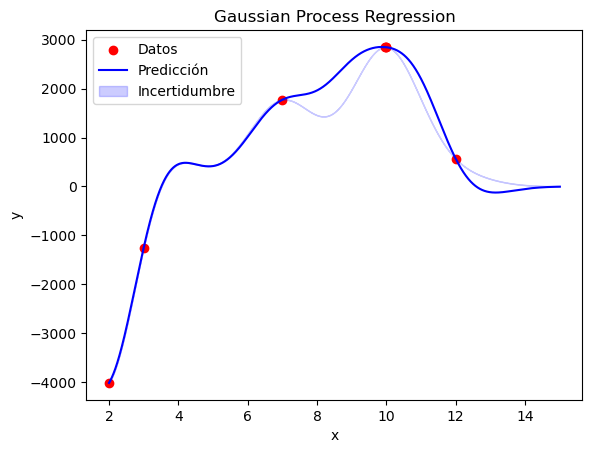

In [98]:
plt.figure()
plt.scatter(x2, y2, color='red', label='Datos')
plt.plot(xsim, ypred2, color='blue', label='Predicción')

plt.fill_between(
    xsim1.ravel(),
    ypred1 + 2*sigma1,
    ypred1 - 2*sigma1,
    color='blue',
    alpha=0.2,
    label='Incertidumbre'
)
plt.legend()
plt.title("Gaussian Process Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Lo más valioso de este modelo no es solo que adivina una curva, sino que cuantifica su propia duda.
Entendí que el Kernel no es solo una fórmula, sino la memoria del modelo. Al configurar el RBF con un ConstantKernel, aprendí a controlar qué tan suave o nerviosa quiero que sea la predicción, adaptándola a la naturaleza de los datos reales.